## Лабораторная работа №1
Выполнил: Закаблукова Анастасия

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import linear_model
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv('insurance.csv')

In [3]:
data.shape

(1338, 7)

In [4]:
display(data.isnull().sum())

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [5]:
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


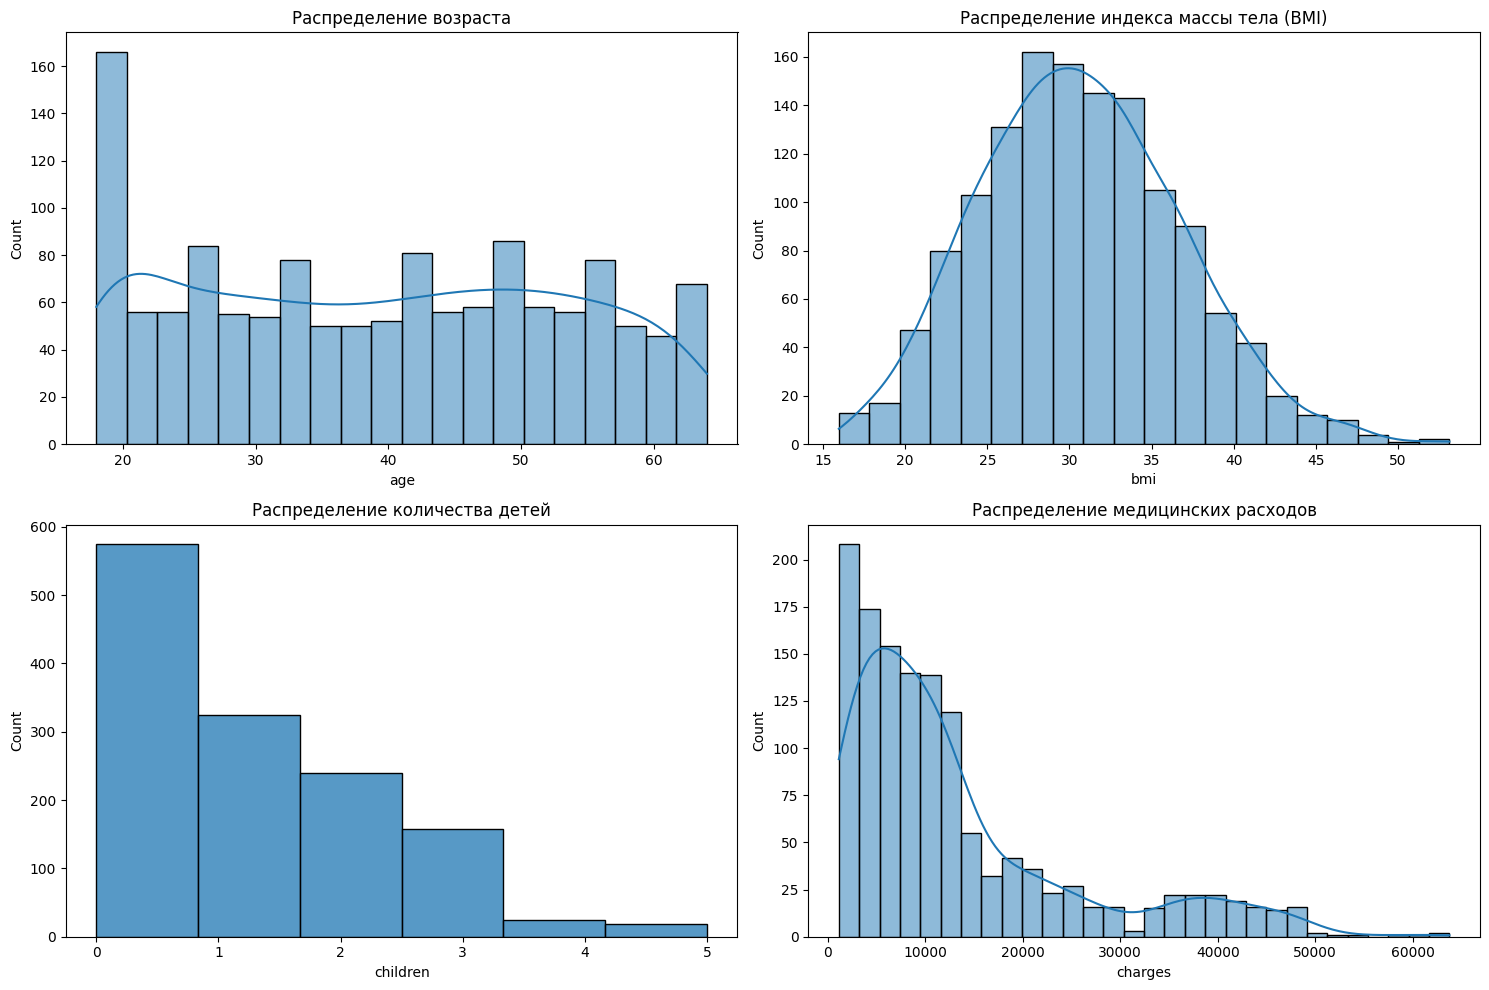

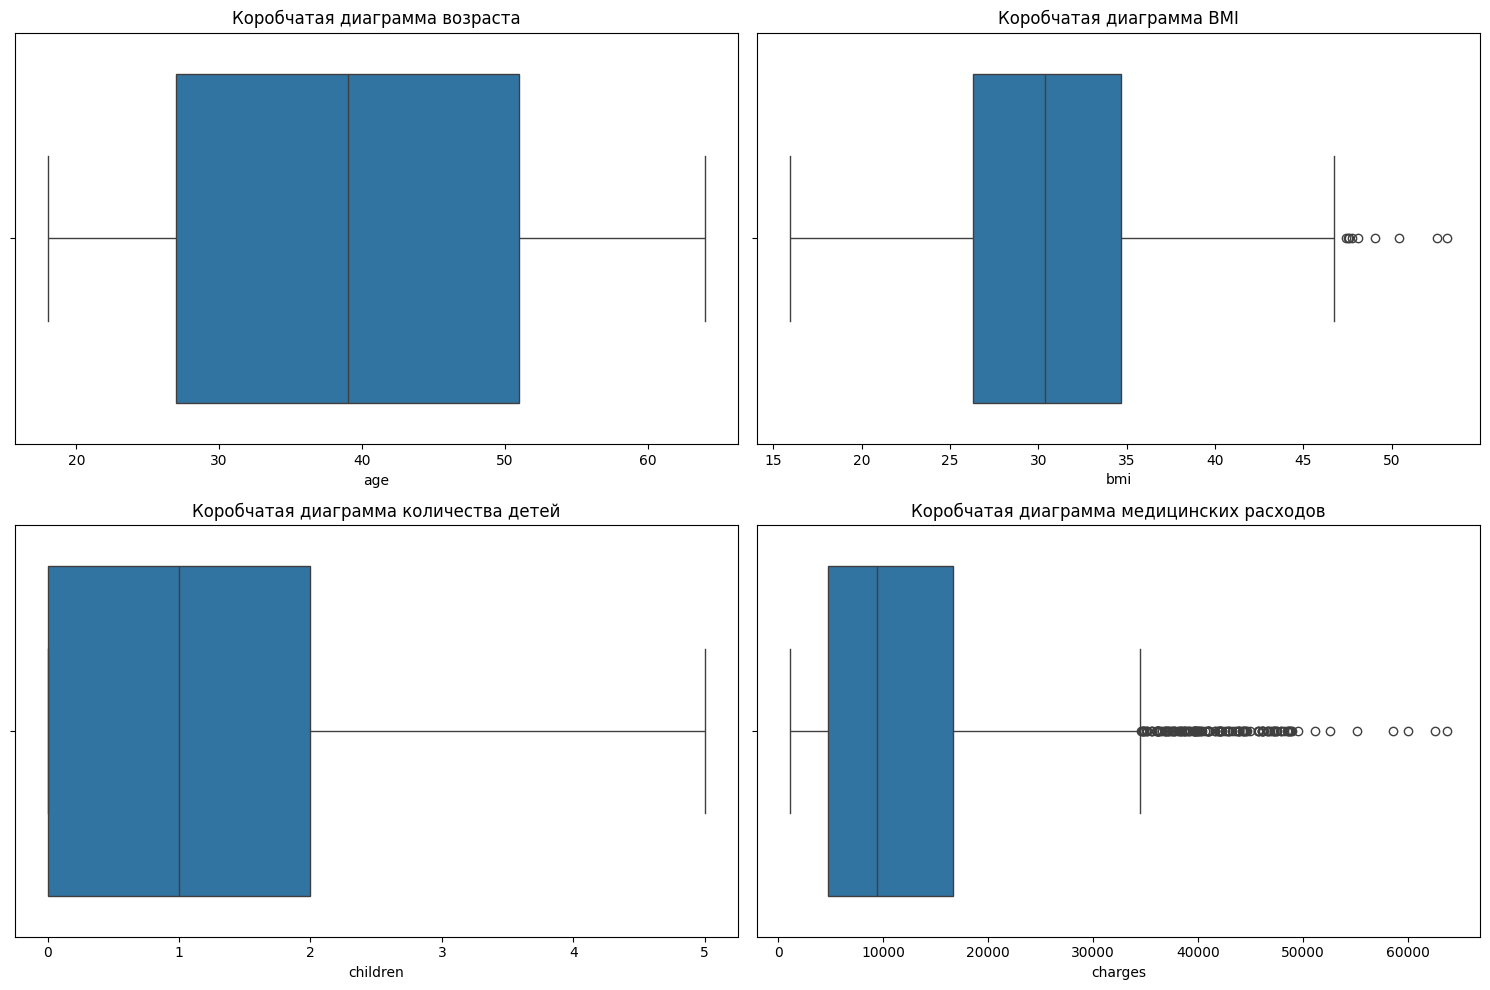

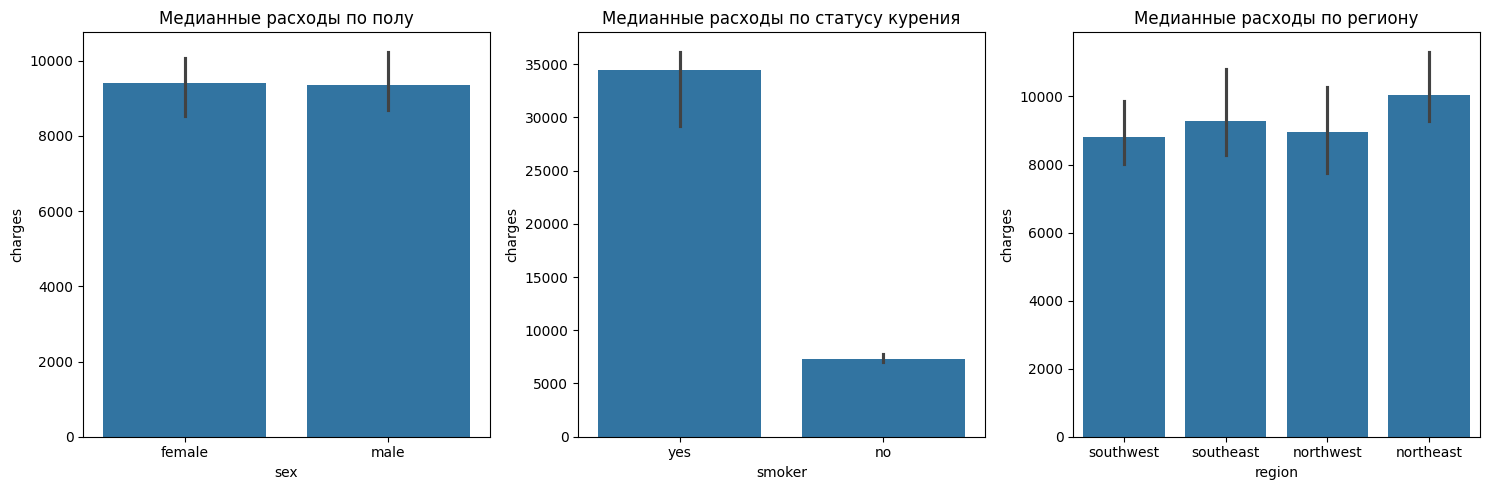

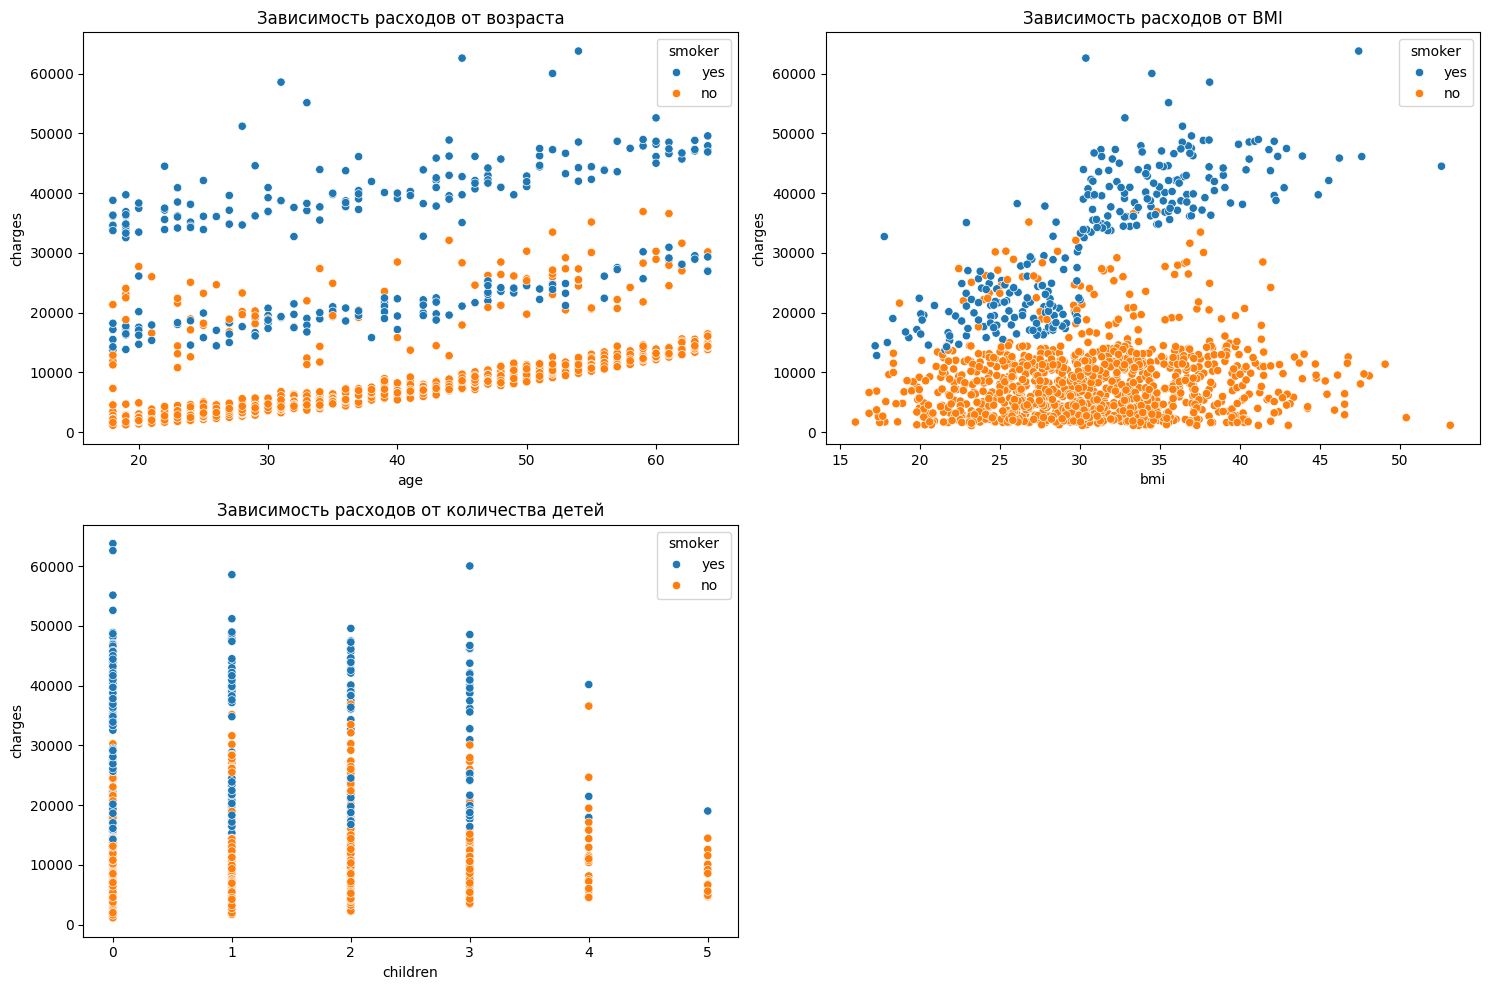

In [8]:
# Гистограммы числовых признаков
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.histplot(data['age'], bins=20, kde=True)
plt.title('Распределение возраста')

plt.subplot(2, 2, 2)
sns.histplot(data['bmi'], bins=20, kde=True)
plt.title('Распределение индекса массы тела (BMI)')

plt.subplot(2, 2, 3)
sns.histplot(data['children'], bins=6, kde=False)
plt.title('Распределение количества детей')

plt.subplot(2, 2, 4)
sns.histplot(data['charges'], bins=30, kde=True)
plt.title('Распределение медицинских расходов')
plt.tight_layout()
plt.show()

# Коробчатые диаграммы числовых признаков
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.boxplot(x=data['age'])
plt.title('Коробчатая диаграмма возраста')

plt.subplot(2, 2, 2)
sns.boxplot(x=data['bmi'])
plt.title('Коробчатая диаграмма BMI')

plt.subplot(2, 2, 3)
sns.boxplot(x=data['children'])
plt.title('Коробчатая диаграмма количества детей')

plt.subplot(2, 2, 4)
sns.boxplot(x=data['charges'])
plt.title('Коробчатая диаграмма медицинских расходов')
plt.tight_layout()
plt.show()

# Медианные расходы по категориальным признакам
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.barplot(x='sex', y='charges', data=data, estimator='median')
plt.title('Медианные расходы по полу')

plt.subplot(1, 3, 2)
sns.barplot(x='smoker', y='charges', data=data, estimator='median')
plt.title('Медианные расходы по статусу курения')

plt.subplot(1, 3, 3)
sns.barplot(x='region', y='charges', data=data, estimator='median')
plt.title('Медианные расходы по региону')
plt.tight_layout()
plt.show()

# Диаграммы рассеяния с учетом курения
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.scatterplot(x='age', y='charges', hue='smoker', data=data)
plt.title('Зависимость расходов от возраста')

plt.subplot(2, 2, 2)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=data)
plt.title('Зависимость расходов от BMI')

plt.subplot(2, 2, 3)
sns.scatterplot(x='children', y='charges', hue='smoker', data=data)
plt.title('Зависимость расходов от количества детей')
plt.tight_layout()
plt.show()

In [10]:
data['smoker'] = data['smoker'].apply(lambda x: 0 if x == 'no' else 1)
data['sex'] = data['sex'].apply(lambda x: 0 if x == 'female' else 1)
data = pd.get_dummies(data)
data.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,1,1725.55230,False,False,True,False
2,28,1,33.000,3,1,4449.46200,False,False,True,False
3,33,1,22.705,0,1,21984.47061,False,True,False,False
4,32,1,28.880,0,1,3866.85520,False,True,False,False


In [11]:
features = data.drop('charges', axis=1).columns
X, y = data[features], data['charges']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state=42
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1070, 9)
Test shape: (268, 9)


In [22]:
lr = linear_model.LinearRegression()
lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)


LinearRegression()

In [23]:
def print_metrics(y_train, y_train_predict, y_test, y_test_predict):
    print('Train R^2: {:.3f}'.format(metrics.r2_score(y_train, y_train_predict)))
    print('Train MAE: {:.3f}'.format(metrics.mean_absolute_error(y_train, y_train_predict)))
    print('Train MAPE: {:.3f}'.format(metrics.mean_absolute_percentage_error(y_train, y_train_predict)*100))
    print('\n')
    print('Test R^2: {:.3f}'.format(metrics.r2_score(y_test, y_test_predict)))
    print('Test MAE: {:.3f}'.format(metrics.mean_absolute_error(y_test, y_test_predict)))
    print('Train MAPE: {:.3f}'.format(metrics.mean_absolute_percentage_error(y_test, y_test_predict)*100))

In [27]:
print_metrics(y_train, y_train_pred, y_test, y_test_pred)

Train R^2: 0.112
Train MAE: 8967.084
Train MAPE: 114.850


Test R^2: 0.158
Test MAE: 9137.215
Train MAPE: 126.967


Text(0, 0.5, 'Model')

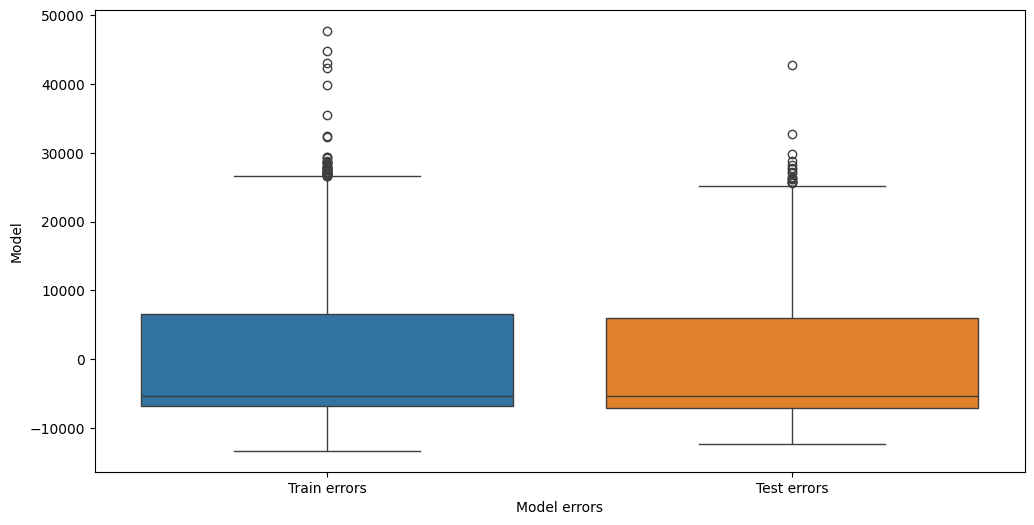

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))
y_train_errors = y_train - y_train_pred
y_test_errors = y_test - y_test_pred
predict_df = pd.DataFrame(
    {'Train errors': y_train_errors,
     'Test errors': y_test_errors
    }
)
sns.boxplot(data=predict_df, ax=ax)
ax.set_xlabel('Model errors')
ax.set_ylabel('Model')

In [29]:
scaler = preprocessing.MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sgd_lr = linear_model.SGDRegressor(random_state=42)
sgd_lr.fit(X_train_scaled, y_train)

y_train_pred_scaled = sgd_lr.predict(X_train_scaled)
y_test_pred_scaled = sgd_lr.predict(X_test_scaled)

print_metrics(y_train, y_train_pred_scaled, y_test, y_test_pred_scaled)

Train R^2: 0.112
Train MAE: 8967.084
Train MAPE: 114.850


Test R^2: 0.158
Test MAE: 9137.215
Train MAPE: 126.967


In [31]:
numeric_cols = ['age', 'bmi', 'children']
binary_cols = ['sex', 'smoker'] + [col for col in X_train.columns if 'region' in col]

poly = preprocessing.PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

X_train_poly = poly.fit_transform(X_train[numeric_cols])
X_test_poly = poly.transform(X_test[numeric_cols])

poly_feature_names = poly.get_feature_names_out(numeric_cols)
X_train_poly = pd.DataFrame(X_train_poly, columns=poly_feature_names, index=X_train.index)
X_test_poly = pd.DataFrame(X_test_poly, columns=poly_feature_names, index=X_test.index)

X_train_final = pd.concat([X_train[binary_cols], X_train_poly], axis=1)
X_test_final = pd.concat([X_test[binary_cols], X_test_poly], axis=1)


In [33]:
poly_model = linear_model.LinearRegression()
poly_model.fit(X_train_final, y_train)

y_train_poly_pred = poly_model.predict(X_train_final)
y_test_poly_pred = poly_model.predict(X_test_final)

print_metrics(y_train, y_train_poly_pred, y_test, y_test_poly_pred)

Train R^2: 0.123
Train MAE: 8899.121
Train MAPE: 116.215


Test R^2: 0.148
Test MAE: 9122.405
Train MAPE: 129.448


In [38]:
lasso_pipe = Pipeline([
    ('poly', preprocessing.PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', preprocessing.StandardScaler()),
    ('lasso', linear_model.Lasso(alpha=1.0, max_iter=2000))
])

lasso_pipe.fit(X_train, y_train)

y_train_lasso_pred = lasso_pipe.predict(X_train)
y_test_lasso_pred = lasso_pipe.predict(X_test)

print_metrics(y_train, y_train_lasso_pred, y_test, y_test_lasso_pred)

Train R^2: 0.128
Train MAE: 8845.945
Train MAPE: 115.791


Test R^2: 0.150
Test MAE: 9115.095
Train MAPE: 129.169


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.978e+07, tolerance: 1.544e+07
  model = cd_fast.enet_coordinate_descent(
